# Strategy 3: Cross-Sectional Momentum

**Thesis.** Stocks that have outperformed *relative to their peers* over
the trailing year tend to keep outperforming relative to those same
peers — a genuinely different bet from Strategy 1's trend-following, which
only cares about an asset's own direction, not its rank among others.

**Signal.** Rank ~500 NYSE stocks by trailing 12-1 month return each
month; long the top decile, short the bottom decile
(`stratlib.backtest.decile_backtest`, same engine used in the
quant-portfolio momentum project).

**What's different about this notebook's robustness checks:** this is a
cross-sectional strategy, not a single-asset one, so "regime" here means
the regime of the *overall market*, not any one stock, and the natural
robustness checks are lookback-length and decile-count sensitivity rather
than a rolling walk-forward on one time series.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from stratlib.backtest import decile_backtest
from stratlib.stats import perf_stats, sharpe_ci
from stratlib.regime import classify_regime, regime_conditional_returns


## 1. Load the equity universe and build the 12-1 momentum signal

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
full_history = px.columns[px.notna().all()]
px = px[full_history]
print(f"Universe: {px.shape[1]} tickers, {px.index.min().date()} to {px.index.max().date()}")

monthly_px = px.resample("ME").last()
monthly_ret = monthly_px.pct_change()

lookback, skip = 12, 1
cum_ret = (1 + monthly_ret).rolling(lookback - skip).apply(np.prod, raw=True) - 1
signal = cum_ret.shift(skip)
fwd_returns = monthly_ret.shift(-1)


Universe: 467 tickers, 2010-01-04 to 2016-12-30


## 2. Backtest

In [3]:
results = decile_backtest(signal, fwd_returns, n_deciles=10, min_names=50)
print(f"{len(results)} monthly rebalances, {results.index.min().date()} to {results.index.max().date()}")

stats_table = pd.DataFrame([
    perf_stats(results["long_short"], freq=12, name="Momentum L/S (D10-D1)"),
    perf_stats(results["decile_9"], freq=12, name="Top decile (long only)"),
    perf_stats(results["decile_0"], freq=12, name="Bottom decile (long only)"),
    perf_stats(results["universe_avg"], freq=12, name="Equal-weight universe (benchmark)"),
]).set_index("name")
stats_table.round(4)


71 monthly rebalances, 2011-01-31 to 2016-11-30


,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
name,,,,,
Momentum L/S (D10-D1),0.0423,0.1535,0.2754,-0.2701,0.5352
Top decile (long only),0.1603,0.1388,1.1543,-0.1725,0.6197
Bottom decile (long only),0.0911,0.1952,0.4665,-0.3426,0.6056
Equal-weight universe (benchmark),0.1279,0.1247,1.0253,-0.1853,0.6197


In [4]:
ci = sharpe_ci(results["long_short"], freq=12, n_boot=3000, ci=0.90, seed=42)
print(f"Long-short Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI:  [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


Long-short Sharpe: 0.275
90% bootstrap CI:  [-0.410, 1.056]


Same finding as the quant-portfolio version of this strategy: the decile
spread is real (monotonic, confirmed by the top-vs-bottom gap), but the
long-short Sharpe's confidence interval straddles zero — 71 monthly
observations isn't enough to call this specific number statistically
proven, even though the underlying signal clearly carries information.

## 3. Regime-conditional performance: does the *market's* regime matter?

Cross-sectional momentum doesn't have its own "regime" the way a
single-asset strategy does — but the overall market it's trading within
does. A synthetic equal-weight market index (the average price across the
whole universe) is classified into the same four regimes used everywhere
else in this repo, and the long-short spread's performance is split by
which regime the *market* was in when each position was taken.

In [5]:
market_index = px.mean(axis=1)
regimes = classify_regime(market_index, trend_window=126, vol_window=21)
monthly_regime = regimes["regime"].resample("ME").last()

# freq=12: this is monthly data, not daily -- passing the wrong freq here
# would silently misstate every annualized figure below.
rc = regime_conditional_returns(results["long_short"], monthly_regime.reindex(results.index), freq=12)
rc[["ann_return", "sharpe", "max_drawdown", "n_obs"]].round(3)


,ann_return,sharpe,max_drawdown,n_obs
regime,,,,
Ranging-HighVol,0.059,0.347,-0.092,9
Ranging-LowVol,-0.103,-0.583,-0.125,11
Trending-HighVol,0.110,0.905,-0.115,31
Trending-LowVol,0.020,0.109,-0.131,20


The market-regime split is noisier than the single-asset regime splits
elsewhere in this repo (each bucket only has 9-31 monthly observations,
versus thousands of daily observations for the single-asset strategies),
so these numbers should be read as suggestive rather than conclusive.
With that caveat: the long-short spread's Sharpe looks meaningfully
better in Trending regimes than Ranging ones in this sample — plausible,
since momentum-style strategies are generally understood to struggle most
during sharp market reversals, which are more common within Ranging
regimes than within an established Trend.

## 4. Robustness: lookback length and number of deciles

In [6]:
lookback_results = []
for lb in [6, 9, 12, 15, 18]:
    cr = (1 + monthly_ret).rolling(lb - skip).apply(np.prod, raw=True) - 1
    sig_lb = cr.shift(skip)
    res_lb = decile_backtest(sig_lb, fwd_returns, n_deciles=10, min_names=50)
    s = perf_stats(res_lb["long_short"], freq=12)
    lookback_results.append({"lookback_months": lb, "sharpe": s["sharpe"], "n_rebalances": len(res_lb)})
lookback_df = pd.DataFrame(lookback_results)
lookback_df


,lookback_months,sharpe,n_rebalances
0,6,0.104670,77
1,9,0.039612,74
2,12,0.275420,71
3,15,0.301190,68
4,18,0.047175,65


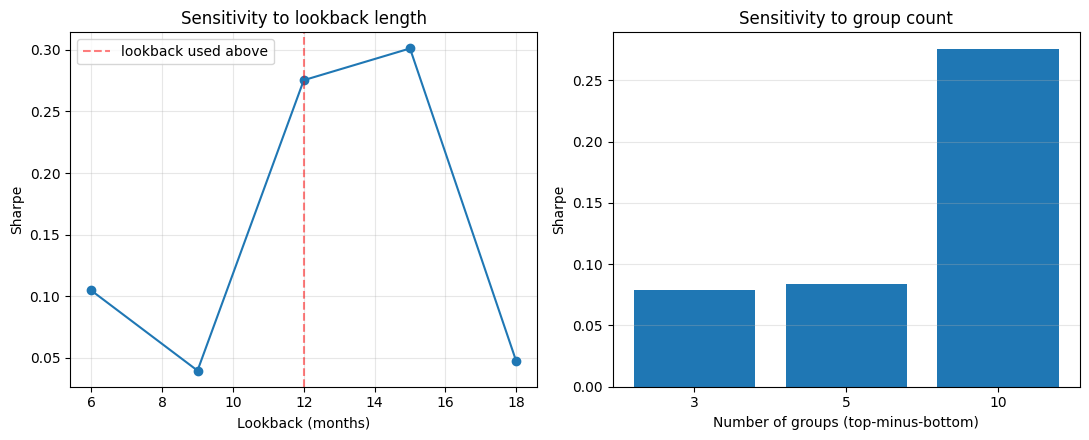

In [7]:
decile_count_results = []
for nd in [3, 5, 10]:
    res_nd = decile_backtest(signal, fwd_returns, n_deciles=nd, min_names=50)
    s = perf_stats(res_nd["long_short"], freq=12)
    decile_count_results.append({"n_groups": nd, "sharpe": s["sharpe"]})
decile_count_df = pd.DataFrame(decile_count_results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(lookback_df["lookback_months"], lookback_df["sharpe"], marker="o")
axes[0].axvline(12, color="red", ls="--", alpha=0.5, label="lookback used above")
axes[0].set_xlabel("Lookback (months)"); axes[0].set_ylabel("Sharpe")
axes[0].set_title("Sensitivity to lookback length"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(decile_count_df["n_groups"].astype(str), decile_count_df["sharpe"])
axes[1].set_xlabel("Number of groups (top-minus-bottom)"); axes[1].set_ylabel("Sharpe")
axes[1].set_title("Sensitivity to group count"); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("xs_momentum_sensitivity.png", dpi=110)
plt.show()


**This is a more concerning sensitivity result than the single-asset
strategies showed.** Sharpe swings from ~0.04 (9-month lookback) to ~0.30
(15-month lookback) — a real range, not a flat plateau, and the direction
isn't monotonic. The 6-decile-count check is more stable (finer decile
cuts consistently outperform coarser tercile cuts here, which makes
intuitive sense — concentrating in the extreme decile captures a stronger
signal than a broader tercile does). The lookback sensitivity is the
more important caveat: it's a real reason for caution about how
precisely-tuned "12-1 months" needs to be treated as a convention
borrowed from the literature (Jegadeesh & Titman, 1993), not a value this
specific sample independently confirms as optimal.

## 5. Discussion: risks and when to use this strategy

**When it's likely to work:** broad, liquid equity universes with
genuine cross-sectional dispersion in recent performance, particularly
during trending market regimes based on the (noisier, more tentative)
regime split above.

**When it's likely to fail:** the short leg specifically is vulnerable
during sharp reversals of previously-losing stocks — exactly the dynamic
that produced this project's most negative single finding: the top decile
alone outperforms the long-short spread in this sample, because shorting
the bottom decile detracted from returns during a period when former
losers staged a recovery.

**Risks and factors:**
- **Lookback-length sensitivity is real here, unlike the single-asset
  strategies in this repo.** Anyone deploying a version of this signal
  should treat the specific lookback as a genuine design choice worth
  testing carefully, not a settled convention.
- **Short-side crash risk (momentum crash).** This is a well-documented,
  serious risk in the academic literature (Daniel & Moskowitz, 2016) —
  momentum strategies can suffer sharp, large drawdowns exactly when
  previously-losing stocks rebound together, and this project's own
  numbers show a mild version of that dynamic.
- **Survivorship bias** in this specific backtest — only tickers with a
  complete history over the full sample are included, which excludes
  delistings and IPOs that a live implementation would have to handle.
- **Capacity and crowding** — cross-sectional momentum is one of the most
  heavily studied and widely traded equity factors; on liquid large-cap
  names, competition for the same signal is a real, ongoing consideration.
- **Turnover and transaction costs** — monthly rebalancing of the extreme
  deciles implies real trading costs that aren't modeled in this
  notebook's gross return figures.
